In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
associate_df = pd.read_csv('./data/ukb.RDH_burden.WBnR.association.continu.HistMTR_0.630_AF0.001.tsv', sep='\t')
associate_df['p_bonferroni'] = associate_df['p_value'].apply(lambda x: min(x * 9, 1.0))

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


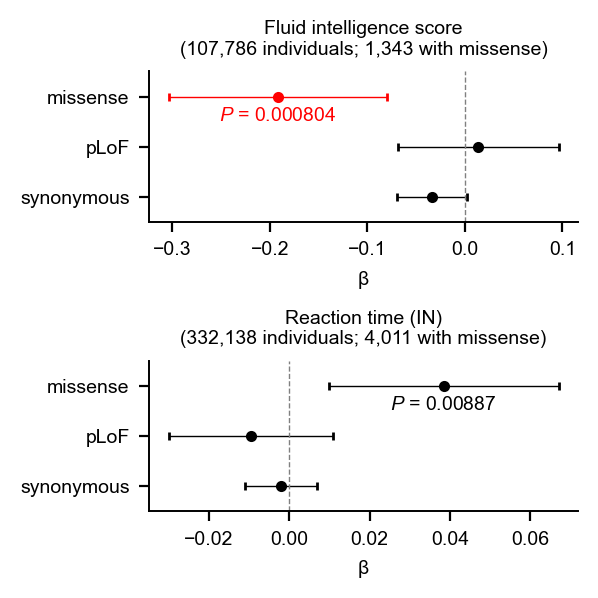

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(3, 3))
axes = axes.flatten()

for idx, phenotype in enumerate([
    'Fluid intelligence score',
    'Reaction time (IN)'
]):

    sub_df = associate_df[associate_df['phenotype'] == phenotype].copy()
    y_pos = np.arange(len(sub_df))

    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(sub_df["variable"])

    for i, row in enumerate(sub_df.itertuples()):
        x = row.beta
        left_error = x - row.beta_ci_lower
        right_error = row.beta_ci_upper - x

        sig = row.p_bonferroni < 0.05
        color = 'red' if sig else 'black'

        axes[idx].errorbar(
            x, y_pos[i],
            xerr=[[left_error], [right_error]],
            fmt='o',
            color=color,
            capsize=1.5,
            linewidth=0.5,
            markersize=3
        )

        if row.p_value < 0.05:
            axes[idx].text(
                x,
                y_pos[i] + 0.2,
                fr'$P$ = {row.p_value:.3g}',
                va='top',
                ha='center',
                fontsize=7,
                color=color
            )

    axes[idx].axvline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[idx].set_xlabel('β')

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.5, 2.5)
    ax.invert_yaxis()

axes[0].set_title(f'Fluid intelligence score\n({associate_df.iloc[0]["#indivi"]:,} individuals; {associate_df.iloc[0]["#indivi_with_variant"]:,} with missense)')
axes[1].set_title(f'Reaction time (IN)\n({associate_df.iloc[1]["#indivi"]:,} individuals; {associate_df.iloc[1]["#indivi_with_variant"]:,} with missense)')

plt.tight_layout()